In [2]:
#Basic Important
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Modeling
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings





In [3]:
df = pd.read_csv('Data/data.csv')

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Preparing X and Y variables

In [5]:
x = df.drop(columns=['math score'],axis=1)


In [9]:
x.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [26]:
import sys
!{sys.executable} -m pip install scikit-learn xgboost catboost


In [7]:
#value of unique values in each column
print("categories in 'gender' variable:  ",end="")
print(df['gender'].unique())

print("categories in 'race/ethnicity' variable:  ",end="")
print(df['race/ethnicity'].unique())

print("categories in 'parental level of education' variable:  ",end="")
print(df['parental level of education'].unique())

print("categories in 'lunch' variable:  ",end="")
print(df['lunch'].unique())

print("categories in 'test preparation course' variable:  ",end="")
print(df['test preparation course'].unique())

print("categories in 'math score' variable:  ",end="")
print(df['math score'].unique())

print("categories in 'reading score' variable:  ",end="")
print(df['reading score'].unique())

print("categories in 'writing score' variable:  ",end="")
print(df['writing score'].unique())

categories in 'gender' variable:  ['female' 'male']
categories in 'race/ethnicity' variable:  ['group B' 'group C' 'group A' 'group D' 'group E']
categories in 'parental level of education' variable:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
categories in 'lunch' variable:  ['standard' 'free/reduced']
categories in 'test preparation course' variable:  ['none' 'completed']
categories in 'math score' variable:  [ 72  69  90  47  76  71  88  40  64  38  58  65  78  50  18  46  54  66
  44  74  73  67  70  62  63  56  97  81  75  57  55  53  59  82  77  33
  52   0  79  39  45  60  61  41  49  30  80  42  27  43  68  85  98  87
  51  99  84  91  83  89  22 100  96  94  48  35  34  86  92  37  28  24
  26  95  36  29  32  93  19  23   8]
categories in 'reading score' variable:  [ 72  90  95  57  78  83  43  64  60  54  52  81  53  75  89  32  42  58
  69  73  71  74  70  65  87  56  61  84  55  44  41  85  59  17  39  80
 

In [8]:
y = df['math score']

In [9]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math score, Length: 1000, dtype: int64

In [10]:
#create column transformer with 3 types of transformers
num_features = x.select_dtypes(exclude='object').columns
cat_features = x.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", categorical_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features)
    ]
)
    

In [11]:
x = preprocessor.fit_transform(x)

In [12]:
x.shape

(1000, 19)

In [13]:
x


array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]], shape=(1000, 19))

In [14]:
#separating data into train and test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((800, 19), (200, 19), (800,), (200,))

Create an Evaluate Function to give all Metrics after Model Training

In [27]:
def evaluate_model(true_values, predicted_values):
    mae = mean_absolute_error(true_values, predicted_values)
    mse = mean_squared_error(true_values, predicted_values)
    rmse = np.sqrt(mse)
    r2 = r2_score(true_values, predicted_values)
    return mae, mse, rmse, r2

In [29]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "KNN Regressor": KNeighborsRegressor(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "AdaBoost Regressor": AdaBoostRegressor(),
    "XGBoost Regressor": XGBRegressor(),
    "CatBoost Regressor": CatBoostRegressor(verbose=0)
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train,y_train) #train model

    #make predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    #evaluate train and test dataset
    model_train_mae, model_train_mse, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_mse, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)


    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('model performance on training set')
    print('- mean absolute error: {:.4f}'.format(model_train_mae))
    print('- root mean squared error: {:.4f}'.format(model_train_rmse))
    print('- R2 score: {:.4f}'.format(model_train_r2))

    print('--------------------------------')

    print('model performance on test set')
    print('- mean absolute error: {:.4f}'.format(model_test_mae))
    print('- root mean squared error: {:.4f}'.format(model_test_rmse))
    print('- R2 score: {:.4f}'.format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
model performance on training set
- mean absolute error: 4.2667
- root mean squared error: 5.3231
- R2 score: 0.8743
--------------------------------
model performance on test set
- mean absolute error: 4.2148
- root mean squared error: 5.3940
- R2 score: 0.8804


Ridge Regression
model performance on training set
- mean absolute error: 4.2650
- root mean squared error: 5.3233
- R2 score: 0.8743
--------------------------------
model performance on test set
- mean absolute error: 4.2111
- root mean squared error: 5.3904
- R2 score: 0.8806


Lasso Regression
model performance on training set
- mean absolute error: 5.2063
- root mean squared error: 6.5938
- R2 score: 0.8071
--------------------------------
model performance on test set
- mean absolute error: 5.1579
- root mean squared error: 6.5197
- R2 score: 0.8253


KNN Regressor
model performance on training set
- mean absolute error: 4.5167
- root mean squared error: 5.7077
- R2 score: 0.8555
----------------------

RESULTS

In [31]:
pd.DataFrame({'Model': model_list, 'R2 Score': r2_list}).sort_values(by='R2 Score', ascending=False)

,Model,R2 Score
1,Ridge Regression,0.880593
0,Linear Regression,0.880433
5,Random Forest Regressor,0.852730
8,CatBoost Regressor,0.851632
6,AdaBoost Regressor,0.845578
7,XGBoost Regressor,0.827797
2,Lasso Regression,0.825320
3,KNN Regressor,0.783813
4,Decision Tree Regressor,0.732903


Linear Regression

In [32]:
lin_model = LinearRegression(fit_intercept=True)
lin_model.fit(x_train,y_train)
y_pred = lin_model.predict(x_test)
score = r2_score(y_test,y_pred)*100
print("accuracy of linear regression model is: {:.2f}%".format(score))



accuracy of linear regression model is: 88.04%


Plot y_pred and y_test

Text(0.5, 1.0, 'Actual vs Predicted Values')

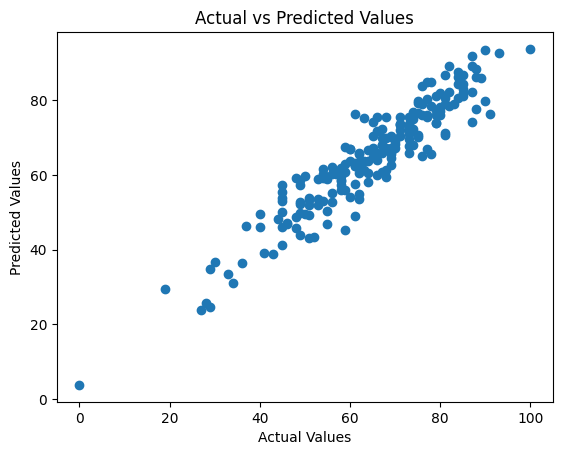

In [33]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")


<Axes: xlabel='math score'>

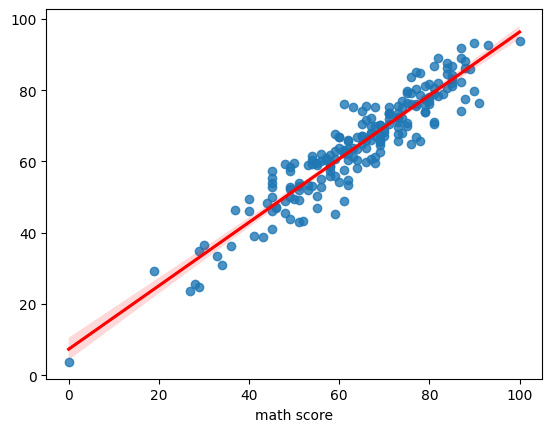

In [34]:
sns.regplot(x=y_test, y=y_pred, line_kws={"color": "red"})

Difference b/w Actual and Predicted Values

In [43]:
pred_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred, 'Difference': y_test - y_pred})
pred_df

,Actual,Predicted,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
